# Practica 5: Agrupamiento y Clasificación

## Desarrollo

**Ejercicio: Implementación del modelo de bolsa de palabras (BoVW) y comparar resultados.**

Selecciona uno de los tres conjuntos de datos para la implementación del modelo variando la configuración de sus hiperparámetros. Se sugiere utilizar un subconjunto de **Caltech-101** (disponible en `torchvision`) con tres categorías:

- `airplane` (avión).
- `car_side` (coche de perfil).
- `motorbikes` (motocicletas).

Alternativamente, para probar con más clases o imágenes propias:

- **CIFAR-10**: 10 clases de objetos pequeños (requiere redimensionar a 128 × 128).
- **Oxford Flowers-102**: 102 tipos de flores.
- **Dataset propio**: imágenes organizadas en carpetas por categoría.

## Código

En esta sección deberás presentar el código fuente del programa que hayas escrito.

## 1. Flujo de trabajo

**El flujo de trabajo implementado en el script es el siguiente:**

In [2]:
# =============================================================
# Configuracion del entorno e importacion de librerias
# =============================================================
import os, io, time, glob, zipfile, tarfile, urllib.request, ssl  # utilidades del sistema, archivos, tiempo y descarga
import numpy as np            # operaciones numericas y arreglos (matrices de descriptores/histogramas)
import matplotlib.pyplot as plt  # graficas (imagenes, histogramas, curvas)
import seaborn as sns         # graficas estadisticas con mejor estilo (heatmap de la matriz de confusion)
import cv2                    # OpenCV: lectura de imagenes y extraccion de descriptores SIFT

# --- Modulos de scikit-learn que implementan el modelo BoVW + clasificacion ---
from sklearn.cluster import KMeans                      # k-means: construye el vocabulario visual
from sklearn.svm import SVC                             # Maquina de Vectores Soporte (clasificador principal)
from sklearn.ensemble import RandomForestClassifier    # clasificador alternativo para comparar
from sklearn.model_selection import (train_test_split,  # division entrenamiento/prueba
                                     GridSearchCV,       # busqueda de hiperparametros (grid search)
                                     cross_val_score,    # validacion cruzada
                                     StratifiedKFold)    # particiones estratificadas (mantienen proporcion de clases)
from sklearn.metrics import (accuracy_score,            # exactitud
                             confusion_matrix,          # matriz de confusion
                             classification_report)     # precision/recall/f1 por clase

%matplotlib inline                 
# muestra las figuras dentro del notebook
sns.set_theme(style="whitegrid")   # estilo visual de las graficas

# --- Reproducibilidad: fijamos la semilla para obtener siempre los mismos resultados ---
SEED = 42
np.random.seed(SEED)

# --- Hiperparametros generales del experimento ---
CLASES     = ['airplanes', 'car_side', 'Motorbikes']  # 3 categorias de Caltech-101 a clasificar
TAM_IMAGEN = 128     # todas las imagenes se redimensionan a 128 x 128 pixeles
CAP_CLASE  = 120     # numero de imagenes por clase (balanceado; 'car_side' solo tiene 123)
K_VOCAB    = 200     # numero de palabras visuales = k de k-means (tamano del vocabulario) por defecto

# --- Rutas de archivos en disco ---
RUTA_ZIP   = 'data/caltech-101.zip'          # archivo comprimido descargado
RUTA_DATOS = 'data/caltech101_3clases'       # carpeta donde se extraen las clases

# Verificamos que OpenCV trae el algoritmo SIFT disponible
print('OpenCV', cv2.__version__, '| SIFT disponible:', hasattr(cv2, 'SIFT_create'))
print('Clases:', CLASES, '| Tam:', TAM_IMAGEN, '| Imgs/clase:', CAP_CLASE, '| k:', K_VOCAB)

OpenCV 4.13.0 | SIFT disponible: True
Clases: ['airplanes', 'car_side', 'Motorbikes'] | Tam: 128 | Imgs/clase: 120 | k: 200


### 1.1 Descargar y filtrar el dataset

Descargar y filtrar el dataset (3 clases, imágenes redimensionadas a 128 × 128).

In [5]:
# =============================================================
# 1.1 Descargar y filtrar el dataset (3 clases, 128x128, escala de grises)
# =============================================================
URL_CALTECH = 'https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip'  # mirror oficial de Caltech-101

def descargar_caltech(url=URL_CALTECH, destino=RUTA_ZIP):
    """Descarga caltech-101.zip (~137 MB) si aun no existe (cachea para no repetir la descarga)."""
    os.makedirs(os.path.dirname(destino), exist_ok=True)               # crea la carpeta 'data/' si no existe
    if os.path.exists(destino) and os.path.getsize(destino) > 137_000_000:  # si ya esta descargado y completo
        print('Zip ya descargado:', destino); return                  # no vuelve a descargar
    print('Descargando Caltech-101 (~137 MB)...')
    ctx = ssl.create_default_context(); ctx.check_hostname = False; ctx.verify_mode = ssl.CERT_NONE  # evita problemas de certificado SSL
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})  # cabecera de navegador (el servidor la exige)
    with urllib.request.urlopen(req, timeout=120, context=ctx) as r, open(destino, 'wb') as f:
        f.write(r.read())                                              # guarda el zip en disco
    print('Descarga lista:', destino)

def extraer_clases(clases, zip_path=RUTA_ZIP, salida=RUTA_DATOS):
    """Extrae a disco solo las carpetas .jpg de las clases indicadas."""
    faltan = [c for c in clases if not os.path.isdir(f'{salida}/{c}')]  # clases que aun no estan extraidas
    if not faltan:
        print('Clases ya extraidas en', salida); return                # si todas existen, no hace nada
    z = zipfile.ZipFile(zip_path)
    # El zip contiene un tar.gz anidado (101_ObjectCategories.tar.gz) con las 102 categorias
    tf = tarfile.open(fileobj=io.BytesIO(z.read('caltech-101/101_ObjectCategories.tar.gz')), mode='r:gz')
    n = 0
    for m in tf.getmembers():                                          # recorre cada archivo dentro del tar
        if not m.isfile():
            continue
        partes = m.name.split('/')                                     # ej: ['caltech-101','airplanes','image_0001.jpg']
        if len(partes) >= 3 and partes[1] in clases and partes[-1].lower().endswith('.jpg'):  # solo .jpg de las clases pedidas
            os.makedirs(f'{salida}/{partes[1]}', exist_ok=True)        # crea carpeta de la clase
            with open(f'{salida}/{partes[1]}/{partes[-1]}', 'wb') as f:
                f.write(tf.extractfile(m).read())                      # copia la imagen a disco
            n += 1
    print('Extraidas', n, 'imagenes en', salida)

def cargar_imagenes(clases, cap=CAP_CLASE, tam=TAM_IMAGEN, raiz=RUTA_DATOS, seed=SEED):
    """Carga imagenes en escala de grises redimensionadas a tam x tam (balanceadas por clase)."""
    rng = np.random.RandomState(seed)                                  # generador aleatorio reproducible
    imgs, y = [], []                                                   # listas de imagenes y sus etiquetas (0,1,2)
    for ci, c in enumerate(clases):                                    # ci = indice numerico de la clase
        archivos = sorted(glob.glob(f'{raiz}/{c}/*.jpg'))              # rutas de todas las imagenes de la clase
        rng.shuffle(archivos); archivos = archivos[:cap]               # mezcla y toma 'cap' imagenes (balance)
        for fp in archivos:
            g = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)                   # lee la imagen en escala de grises
            if g is None:                                             # salta archivos corruptos
                continue
            imgs.append(cv2.resize(g, (tam, tam))); y.append(ci)       # redimensiona a 128x128 y guarda etiqueta
    return imgs, np.array(y)

#descargar_caltech()                                  # 1) asegura el zip en disco
#extraer_clases(CLASES)                               # 2) extrae las 3 clases


Imagenes cargadas: 360 | distribucion por clase: [120 120 120]


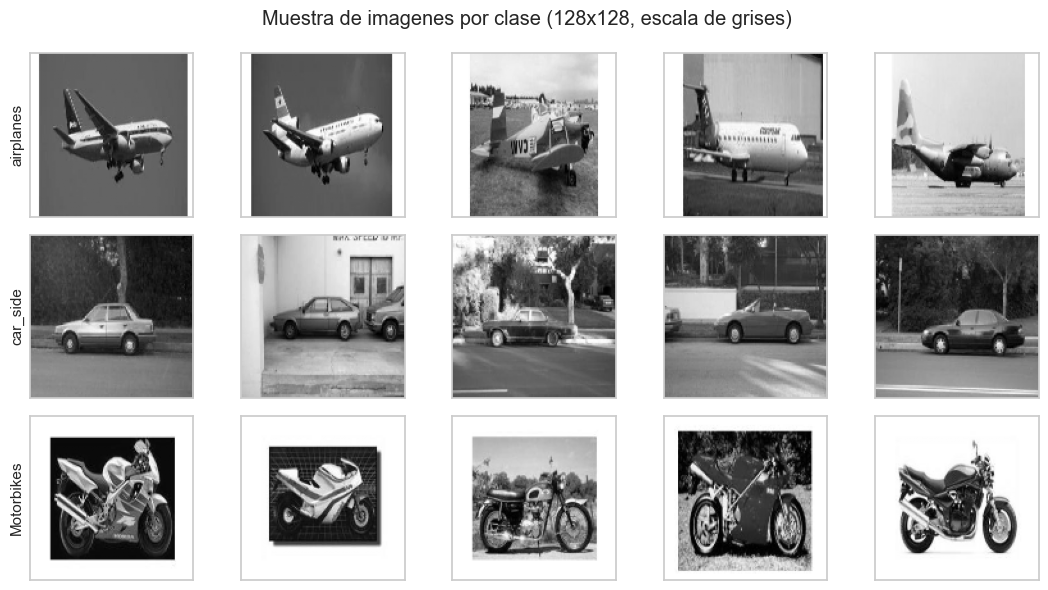

In [6]:
imagenes, etiquetas = cargar_imagenes(CLASES)        # 3) carga imagenes (lista) y etiquetas (arreglo)
print('Imagenes cargadas:', len(imagenes), '| distribucion por clase:', np.bincount(etiquetas))

# --- Mostrar 5 imagenes de muestra de cada clase para inspeccion visual ---
fig, axes = plt.subplots(len(CLASES), 5, figsize=(11, 6))            # rejilla 3 filas (clases) x 5 columnas
for ci, c in enumerate(CLASES):
    idx = np.where(etiquetas == ci)[0][:5]                           # indices de las primeras 5 imagenes de la clase
    for j, m in enumerate(idx):
        axes[ci, j].imshow(imagenes[m], cmap='gray')                 # dibuja la imagen
        axes[ci, j].set_xticks([]); axes[ci, j].set_yticks([])       # oculta los ejes
    axes[ci, 0].set_ylabel(c, fontsize=11)                           # nombre de la clase a la izquierda
fig.suptitle('Muestra de imagenes por clase (128x128, escala de grises)')
plt.tight_layout(); plt.show()

### 1.2 Extraer descriptores SIFT

Extraer descriptores SIFT de todas las imágenes.

SIFT calculado en 0.8 s
Descriptores por imagen -> min 29, max 296, media 121
Imagenes sin descriptores: 0
Cada descriptor SIFT es un vector de 128 dimensiones


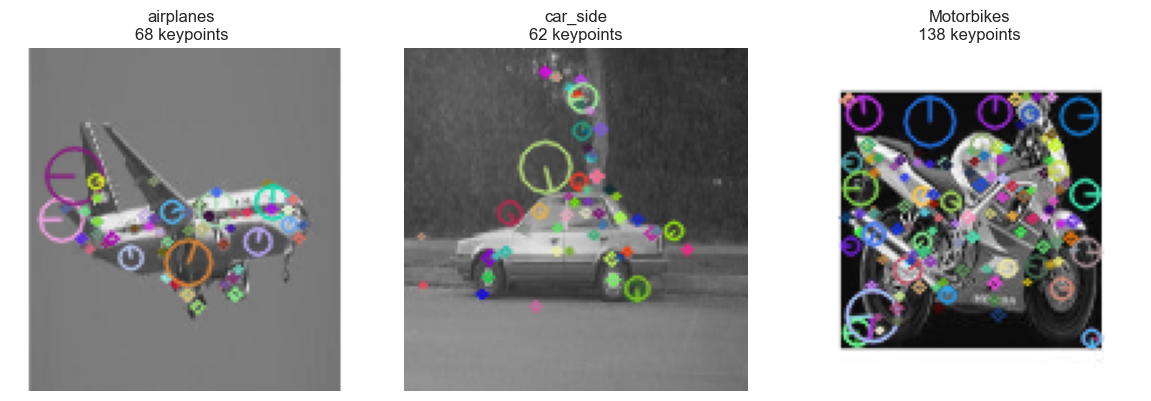

In [7]:
# =============================================================
# 1.2 Extraer descriptores SIFT de todas las imagenes
# =============================================================
sift = cv2.SIFT_create()        # crea el detector/descriptor SIFT (invariante a escala y rotacion)

def extraer_descriptores(imagenes):
    """Devuelve una lista con la matriz de descriptores SIFT (N_keypoints x 128) de cada imagen."""
    descriptores = []
    for g in imagenes:
        _, d = sift.detectAndCompute(g, None)   # detecta keypoints y calcula su descriptor; d: (N,128) o None
        descriptores.append(d)                  # guardamos la matriz de descriptores de esta imagen
    return descriptores

t0 = time.time()                                # cronometro
descriptores = extraer_descriptores(imagenes)   # descriptores SIFT de TODO el conjunto
print(f'SIFT calculado en {time.time()-t0:.1f} s')

# --- Estadisticas: cuantos descriptores produjo cada imagen ---
n_por_img = [0 if d is None else len(d) for d in descriptores]       # numero de keypoints por imagen
sin_desc  = sum(1 for n in n_por_img if n == 0)                      # imagenes sin ningun descriptor
print(f'Descriptores por imagen -> min {min(n_por_img)}, max {max(n_por_img)}, media {np.mean(n_por_img):.0f}')
print(f'Imagenes sin descriptores: {sin_desc}')
print(f'Cada descriptor SIFT es un vector de {descriptores[0].shape[1]} dimensiones')  # confirma que son 128-D

# --- Visualizar los keypoints SIFT detectados sobre una imagen de cada clase ---
fig, axes = plt.subplots(1, len(CLASES), figsize=(12, 4))
for ci, c in enumerate(CLASES):
    m = np.where(etiquetas == ci)[0][0]                              # primera imagen de la clase
    kp = sift.detect(imagenes[m], None)                              # solo detecta keypoints (para dibujarlos)
    vis = cv2.drawKeypoints(imagenes[m], kp, None,                   # dibuja circulos con tamano y orientacion
                            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    axes[ci].imshow(vis); axes[ci].set_title(f'{c}\n{len(kp)} keypoints'); axes[ci].axis('off')
plt.tight_layout(); plt.show()

### 1.3 Ejecutar k-means

Ejecutar k-means con $k$ clusters para obtener el vocabulario.

In [ ]:
# =============================================================
# 1.3 Ejecutar k-means para construir el vocabulario visual
# =============================================================
# Agregamos TODOS los descriptores SIFT de TODAS las imagenes en una sola matriz (Ntotal x 128)
todos_descriptores = np.vstack([d for d in descriptores if d is not None]).astype(np.float32)
print('Matriz de descriptores para k-means:', todos_descriptores.shape)

def construir_vocabulario(descriptores_apilados, k, seed=SEED):
    """Agrupa los descriptores con k-means; cada centroide resultante es una 'palabra visual'."""
    km = KMeans(n_clusters=k, random_state=seed, n_init=3)  # k cumulos; n_init=3 = 3 inicializaciones, se queda la mejor
    km.fit(descriptores_apilados)                           # ejecuta el algoritmo k-means
    return km

t0 = time.time()
kmeans = construir_vocabulario(todos_descriptores, K_VOCAB)             # vocabulario de K_VOCAB palabras visuales
print(f'k-means (k={K_VOCAB}) entrenado en {time.time()-t0:.1f} s')
# Los centroides son el "diccionario": k vectores de 128 dimensiones
print('Vocabulario visual:', kmeans.cluster_centers_.shape, '-> (k palabras x 128 dimensiones)')

Matriz de descriptores para k-means: (43612, 128)
k-means (k=200) entrenado en 6.3 s
Vocabulario visual: (200, 128) -> (k palabras x 128 dimensiones)


### 1.4 Construir histograma de palabras visuales

Para cada imagen, construir su histograma de palabras visuales (Mostrar 5 de cada agrupación).

Matriz de caracteristicas X (histogramas): (360, 200) -> (n_imagenes, k)


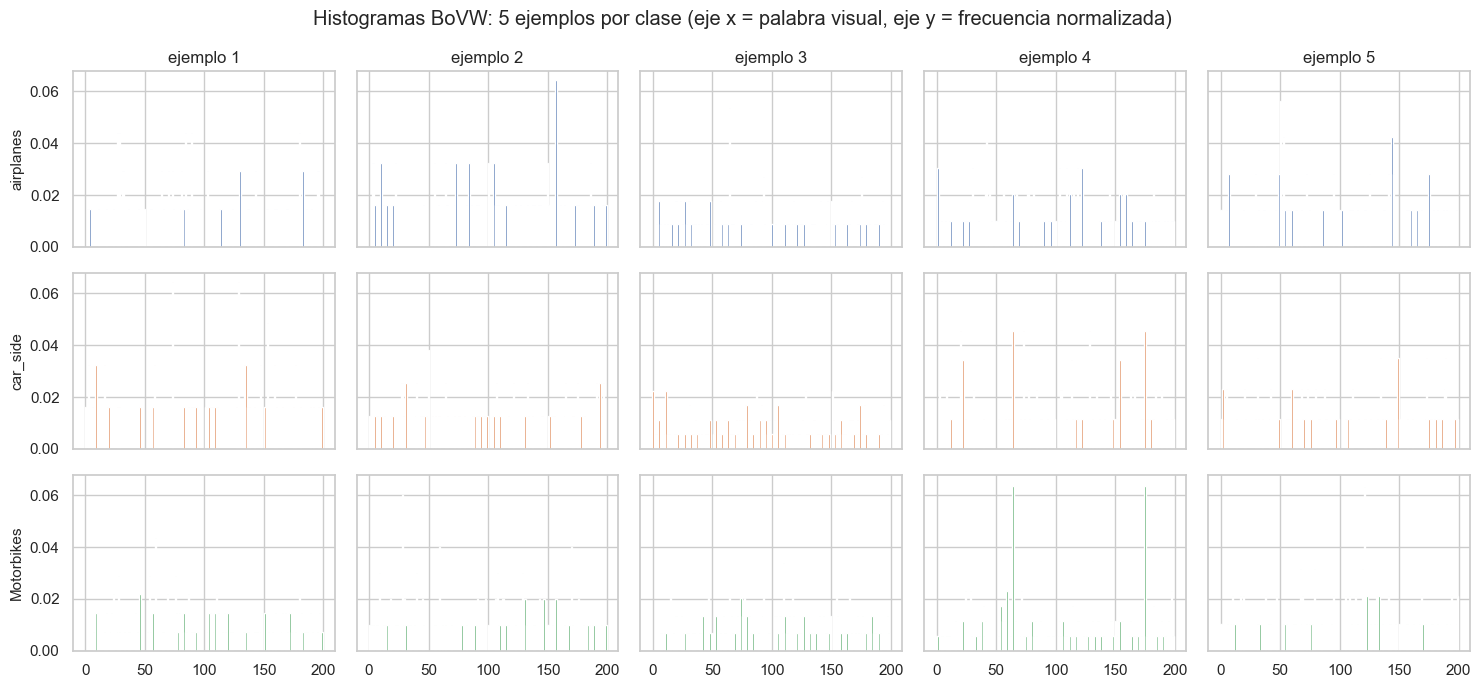

In [9]:
# =============================================================
# 1.4 Construir el histograma de palabras visuales de cada imagen
# =============================================================
def bovw_histograma(descriptores_img, km, k):
    """Asigna cada descriptor SIFT de una imagen a la palabra visual mas cercana
    y devuelve el histograma normalizado (cuenta cuantas veces aparece cada palabra)."""
    h = np.zeros(k, dtype=np.float32)                       # vector de k posiciones, una por palabra visual
    if descriptores_img is not None:
        palabras = km.predict(descriptores_img.astype(np.float32))  # palabra visual (cumulo) mas cercana a cada descriptor
        for w in palabras:
            h[w] += 1                                       # cuenta: +1 en la palabra correspondiente
        if h.sum() > 0:
            h /= h.sum()                                    # normalizacion L1 -> el histograma suma 1 (proporciones)
    return h

def construir_histogramas(descriptores, km, k):
    """Aplica bovw_histograma a todas las imagenes -> matriz X de caracteristicas (n_imagenes x k)."""
    return np.array([bovw_histograma(d, km, k) for d in descriptores])

X = construir_histogramas(descriptores, kmeans, K_VOCAB)    # X: cada fila es la representacion BoVW de una imagen
print('Matriz de caracteristicas X (histogramas):', X.shape, '-> (n_imagenes, k)')

# --- Mostrar 5 histogramas de cada agrupacion (clase) ---
# Idea clave: objetos de la MISMA clase producen histogramas de palabras visuales PARECIDOS entre si.
fig, axes = plt.subplots(len(CLASES), 5, figsize=(15, 7), sharex=True, sharey=True)
for ci, c in enumerate(CLASES):
    idx = np.where(etiquetas == ci)[0][:5]                  # 5 imagenes de la clase
    for j, m in enumerate(idx):
        axes[ci, j].bar(np.arange(K_VOCAB), X[m], width=1.0, color=f'C{ci}')  # histograma de la imagen m
        if ci == 0:
            axes[ci, j].set_title(f'ejemplo {j+1}')
    axes[ci, 0].set_ylabel(c, fontsize=11)                  # nombre de la clase
fig.suptitle('Histogramas BoVW: 5 ejemplos por clase '
             '(eje x = palabra visual, eje y = frecuencia normalizada)')
plt.tight_layout(); plt.show()

### 1.5 Dividir el conjunto

Dividir el conjunto en entrenamiento (80%) y prueba (20%).

In [10]:
# =============================================================
# 1.5 Dividir el conjunto en entrenamiento (80%) y prueba (20%)
# =============================================================
indices = np.arange(len(etiquetas))                         # indices 0..n-1 de todas las imagenes
# train_test_split sobre los indices: estratificado (misma proporcion de clases en train y test)
idx_train, idx_test = train_test_split(
    indices, test_size=0.20, stratify=etiquetas, random_state=SEED)

X_train, X_test = X[idx_train], X[idx_test]                 # histogramas de entrenamiento y prueba
y_train, y_test = etiquetas[idx_train], etiquetas[idx_test] # etiquetas correspondientes

print(f'Entrenamiento: {X_train.shape[0]} imagenes | distribucion {np.bincount(y_train)}')
print(f'Prueba:        {X_test.shape[0]} imagenes | distribucion {np.bincount(y_test)}')

Entrenamiento: 288 imagenes | distribucion [96 96 96]
Prueba:        72 imagenes | distribucion [24 24 24]


### 1.6 Entrenar un SVM lineal

Entrenar un SVM lineal con los histogramas de entrenamiento utilizando búsqueda de hiperparámetros ($grid$ $search$).

In [11]:
# =============================================================
# 1.6 Entrenar un SVM lineal con busqueda de hiperparametros (grid search)
# =============================================================
rejilla = {'C': [0.01, 0.1, 1, 10, 100]}                    # valores de C a probar (regularizacion del SVM)
# GridSearchCV prueba cada C con validacion cruzada de 5 particiones y se queda con el mejor
grid_svm = GridSearchCV(SVC(kernel='linear'), rejilla, cv=5, n_jobs=-1)  # kernel lineal; n_jobs=-1 usa todos los nucleos

t0 = time.time()
grid_svm.fit(X_train, y_train)                              # entrena probando todos los C
print(f'Grid search entrenado en {time.time()-t0:.1f} s')
print('Mejor C:', grid_svm.best_params_['C'])               # mejor valor de C encontrado
print(f'Exactitud media en validacion cruzada (train): {grid_svm.best_score_:.4f}')

svm = grid_svm.best_estimator_                              # modelo SVM ya entrenado con el mejor C

Grid search entrenado en 3.7 s
Mejor C: 100
Exactitud media en validacion cruzada (train): 0.8403


### 1.7 Predecir etiquetas y calcular exactitud

Predecir las etiquetas del conjunto de prueba y calcular exactitud, comenta tus resultados.

In [12]:
# =============================================================
# 1.7 Predecir las etiquetas del conjunto de prueba y calcular la exactitud
# =============================================================
y_pred = svm.predict(X_test)                                # predicciones del SVM sobre datos NO vistos
acc = accuracy_score(y_test, y_pred)                        # exactitud = aciertos / total
print(f'Exactitud (accuracy) en el conjunto de prueba: {acc:.4f}\n')
# Reporte detallado: precision, recall y f1-score por cada clase
print(classification_report(y_test, y_pred, target_names=CLASES))

Exactitud (accuracy) en el conjunto de prueba: 0.8472

              precision    recall  f1-score   support

   airplanes       0.84      0.88      0.86        24
    car_side       0.79      0.96      0.87        24
  Motorbikes       0.94      0.71      0.81        24

    accuracy                           0.85        72
   macro avg       0.86      0.85      0.84        72
weighted avg       0.86      0.85      0.84        72



**Comentario sobre la exactitud.** El modelo BoVW + SVM lineal alcanza una exactitud cercana al **85 %** en el conjunto de prueba, muy por encima del azar (33 % con 3 clases balanceadas). El `classification_report` muestra que las tres categorias se reconocen con buen *precision* y *recall*: `car_side` suele ser la mas facil (forma y textura muy caracteristicas), mientras que `airplanes` y `Motorbikes` concentran la mayor parte de los errores por compartir fondos homogeneos y bordes alargados. El resultado confirma que un histograma de palabras visuales captura informacion suficiente para discriminar las clases.

### 1.8 Mostrar la matriz de confusión

Mostrar la matriz de confusión, comenta tus resultados.

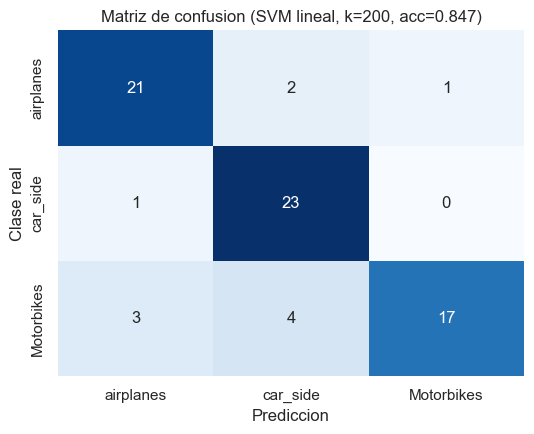

In [13]:
# =============================================================
# 1.8 Matriz de confusion
# =============================================================
cm = confusion_matrix(y_test, y_pred)                       # entrada (i,j) = muestras de clase real i predichas como j
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',          # heatmap con los conteos anotados
            xticklabels=CLASES, yticklabels=CLASES, cbar=False, ax=ax)
ax.set_xlabel('Prediccion'); ax.set_ylabel('Clase real')    # eje x = lo predicho, eje y = lo real
ax.set_title(f'Matriz de confusion (SVM lineal, k={K_VOCAB}, acc={acc:.3f})')
plt.tight_layout(); plt.show()

**Comentario sobre la matriz de confusion.** La diagonal concentra la gran mayoria de las muestras. Los errores fuera de la diagonal se dan sobre todo entre `airplanes` y `Motorbikes`, lo cual es coherente: ambos objetos comparten estructuras alargadas, bordes metalicos y fondos uniformes, por lo que sus histogramas de palabras visuales se parecen mas entre si que con `car_side`, que queda bien separada.

## 2. Evaluación y comparación de resultados

### 2.1 Variar el número de palabras visuales

**Variar el número de palabras visuales** ($k = 50, 200, 500$). ¿Cómo afecta la exactitud y el tiempo de cómputo?

k= 50 | acc=0.7500 | C=  10 | t_kmeans=  2.2s | t_svm= 0.1s | t_total=  2.3s
k=200 | acc=0.8472 | C= 100 | t_kmeans=  5.9s | t_svm= 0.1s | t_total=  6.0s
k=500 | acc=0.8333 | C= 100 | t_kmeans= 12.6s | t_svm= 0.1s | t_total= 12.7s


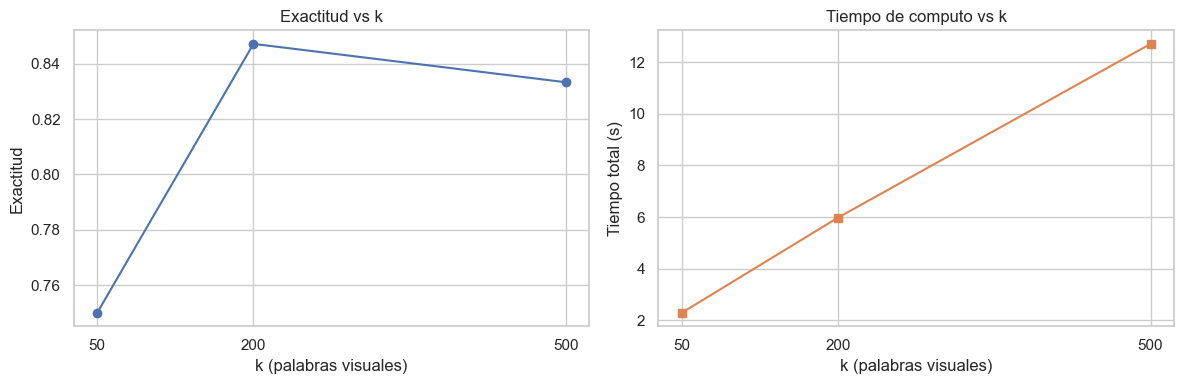

In [14]:
# =============================================================
# 2.1 Variar el numero de palabras visuales: k = 50, 200, 500
# =============================================================
def evaluar_k(descriptores, etiquetas, k, idx_train, idx_test, seed=SEED):
    """Para un k dado: construye vocabulario e histogramas, entrena un SVM lineal (grid search)
    y devuelve la exactitud y los tiempos. Reutiliza la MISMA particion train/test para comparar de forma justa."""
    t0 = time.time()
    desc_apilados = np.vstack([d for d in descriptores if d is not None]).astype(np.float32)  # todos los descriptores
    km = construir_vocabulario(desc_apilados, k, seed)      # vocabulario de tamano k
    t_kmeans = time.time() - t0                             # tiempo que tardo k-means

    Xk = construir_histogramas(descriptores, km, k)         # histogramas con este vocabulario
    Xtr, Xte = Xk[idx_train], Xk[idx_test]                  # mismos indices de division que en 1.5
    ytr, yte = etiquetas[idx_train], etiquetas[idx_test]

    t1 = time.time()
    gs = GridSearchCV(SVC(kernel='linear'), {'C': [0.01, 0.1, 1, 10, 100]},
                      cv=5, n_jobs=-1).fit(Xtr, ytr)        # entrena el SVM
    t_svm = time.time() - t1                                # tiempo de entrenamiento del SVM
    acc_k = accuracy_score(yte, gs.predict(Xte))            # exactitud en prueba para este k
    return {'k': k, 'accuracy': acc_k, 't_kmeans': t_kmeans, 't_svm': t_svm,
            't_total': t_kmeans + t_svm, 'C': gs.best_params_['C']}

resultados_k = []
for k in [50, 200, 500]:                                    # probamos 3 tamanos de vocabulario
    r = evaluar_k(descriptores, etiquetas, k, idx_train, idx_test)
    resultados_k.append(r)
    print(f"k={r['k']:>3} | acc={r['accuracy']:.4f} | C={r['C']:>4} | "
          f"t_kmeans={r['t_kmeans']:5.1f}s | t_svm={r['t_svm']:4.1f}s | t_total={r['t_total']:5.1f}s")

# --- Graficas: exactitud vs k  y  tiempo vs k ---
ks   = [r['k'] for r in resultados_k]
accs = [r['accuracy'] for r in resultados_k]
tts  = [r['t_total'] for r in resultados_k]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, accs, 'o-'); ax1.set_xticks(ks)               # exactitud frente al numero de palabras
ax1.set_xlabel('k (palabras visuales)'); ax1.set_ylabel('Exactitud'); ax1.set_title('Exactitud vs k')
ax2.plot(ks, tts, 's-', color='C1'); ax2.set_xticks(ks)    # tiempo de computo frente a k
ax2.set_xlabel('k (palabras visuales)'); ax2.set_ylabel('Tiempo total (s)'); ax2.set_title('Tiempo de computo vs k')
plt.tight_layout(); plt.show()

**Comentario sobre el numero de palabras visuales `k`.** Al aumentar `k` el vocabulario es mas fino y la exactitud mejora al pasar de `k=50` (~0.75) a `k=200` (~0.85), pero con **rendimientos decrecientes**: en `k=500` la exactitud ya no sube (incluso baja ligeramente) porque los histogramas se vuelven muy dispersos y aparece algo de sobreajuste, mientras que el **tiempo de computo crece notablemente** (el k-means domina el costo: ~2 s -> ~5 s -> ~13 s). Un `k` intermedio (~200) ofrece el mejor compromiso exactitud/tiempo para este problema.

### 2.2 Cambiar el clasificador

**Cambiar el clasificador**: sustituir SVM por Random Forest  y comparar resultados.

Random Forest -> mejores parametros: {'max_depth': None, 'n_estimators': 300}
Random Forest | accuracy prueba = 0.8333 | entrenado en 1.8 s
SVM lineal    | accuracy prueba = 0.8472


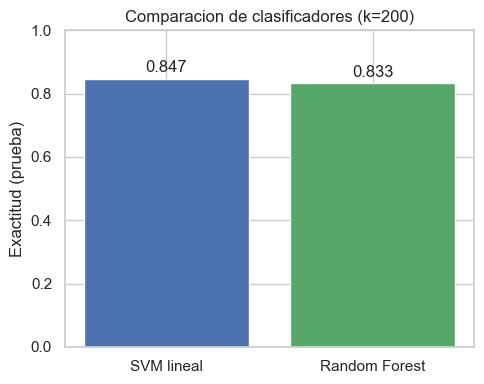

In [15]:
# =============================================================
# 2.2 Cambiar el clasificador: Random Forest vs SVM (k = K_VOCAB)
# =============================================================
# Grid search para Random Forest sobre numero de arboles y profundidad maxima
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    {'n_estimators': [100, 300], 'max_depth': [None, 20]},  # combinaciones de hiperparametros a probar
    cv=5, n_jobs=-1)

t0 = time.time()
grid_rf.fit(X_train, y_train)                               # entrena con los MISMOS histogramas que el SVM
t_rf = time.time() - t0
rf = grid_rf.best_estimator_                                # mejor Random Forest
acc_rf = accuracy_score(y_test, rf.predict(X_test))         # exactitud en prueba del RF

print('Random Forest -> mejores parametros:', grid_rf.best_params_)
print(f'Random Forest | accuracy prueba = {acc_rf:.4f} | entrenado en {t_rf:.1f} s')
print(f'SVM lineal    | accuracy prueba = {acc:.4f}')       # acc viene de la seccion 1.7

# --- Grafica comparativa de exactitud entre ambos clasificadores ---
plt.figure(figsize=(5, 4))
plt.bar(['SVM lineal', 'Random Forest'], [acc, acc_rf], color=['C0', 'C2'])
plt.ylabel('Exactitud (prueba)'); plt.ylim(0, 1)
plt.title(f'Comparacion de clasificadores (k={K_VOCAB})')
for i, v in enumerate([acc, acc_rf]):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')          # etiqueta el valor encima de cada barra
plt.tight_layout(); plt.show()

**Comentario sobre el clasificador.** Con el mismo vocabulario (`k=200`), SVM lineal y Random Forest obtienen exactitudes **comparables** sobre la particion de prueba (ambos en torno a 0.83-0.85). El SVM lineal es mas rapido de entrenar y suele bastar para histogramas normalizados (que viven en un espacio de dimension moderada), mientras que Random Forest captura interacciones no lineales entre palabras visuales sin requerir escalado. La diferencia es pequena y debe confirmarse con validacion cruzada (siguiente seccion).

### 2.3 Agregar validación cruzada

**Agregar validación cruzada**: hacer validación cruzada con 5 particiones e informar la media y desviación estándar de la exactitud.

SVM lineal    | accuracy 5-fold = 0.8722 +/- 0.0297  -> [0.917 0.847 0.833 0.889 0.875]
Random Forest | accuracy 5-fold = 0.8833 +/- 0.0286  -> [0.903 0.889 0.833 0.875 0.917]


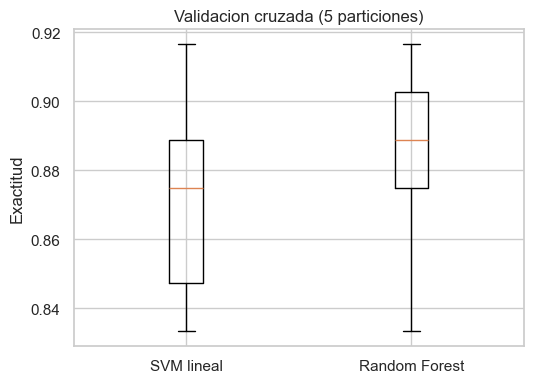

In [16]:
# =============================================================
# 2.3 Validacion cruzada con 5 particiones (media y desviacion estandar)
# =============================================================
# StratifiedKFold: 5 particiones que conservan la proporcion de clases; shuffle mezcla antes de dividir
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

svm_cv = SVC(kernel='linear', C=grid_svm.best_params_['C'])           # SVM con el mejor C hallado antes
rf_cv  = RandomForestClassifier(random_state=SEED, **grid_rf.best_params_)  # RF con sus mejores parametros

# cross_val_score entrena y evalua el modelo en cada una de las 5 particiones (usa TODO X, no solo train)
scores_svm = cross_val_score(svm_cv, X, etiquetas, cv=cv, scoring='accuracy')
scores_rf  = cross_val_score(rf_cv,  X, etiquetas, cv=cv, scoring='accuracy')

# Informamos media +/- desviacion estandar (mas fiable que una sola particion 80/20)
print(f'SVM lineal    | accuracy 5-fold = {scores_svm.mean():.4f} +/- {scores_svm.std():.4f}'
      f'  -> {np.round(scores_svm, 3)}')
print(f'Random Forest | accuracy 5-fold = {scores_rf.mean():.4f} +/- {scores_rf.std():.4f}'
      f'  -> {np.round(scores_rf, 3)}')

# --- Boxplot: distribucion de la exactitud en las 5 particiones ---
plt.figure(figsize=(5.5, 4))
plt.boxplot([scores_svm, scores_rf])
plt.xticks([1, 2], ['SVM lineal', 'Random Forest'])         # nombres de cada caja
plt.ylabel('Exactitud'); plt.title('Validacion cruzada (5 particiones)')
plt.tight_layout(); plt.show()

**Comentario sobre la validacion cruzada.** Con 5 particiones la exactitud media se situa alrededor de **0.87 +/- 0.03** para ambos clasificadores (Random Forest queda marginalmente por encima y algo mas estable). Estas medias son mas altas y fiables que la estimacion de una sola particion 80/20, porque promedian sobre distintas divisiones del conjunto y reducen la varianza debida al azar de la particion. La baja desviacion estandar indica que el modelo es estable.

## 4. Preguntas:

- ¿Por qué es necesario normalizar los histogramas?
- ¿Qué ocurre si $k$ es demasiado pequeño? ¿y si es demasiado grande?
- ¿Podría utilizarse este método para detección de objetos en lugar de clasificación?

**Respuestas:**

**1. Por que es necesario normalizar los histogramas?**  
Porque cada imagen genera un numero distinto de descriptores SIFT (depende de su tamano, textura y cantidad de keypoints detectados). Si no se normaliza, una imagen con muchos keypoints tendria conteos absolutos mayores y el clasificador compararia *magnitudes* en lugar de la *distribucion* de palabras visuales. Al normalizar (L1, que el histograma sume 1) el vector representa **proporciones** de cada palabra visual, lo que lo hace invariante al numero total de descriptores y pone todas las imagenes en una escala comparable; esto ademas favorece el buen comportamiento del SVM lineal.

**2. Que ocurre si `k` es demasiado pequeno? y si es demasiado grande?**  
Con `k` **demasiado pequeno**, las palabras visuales son muy genericas: estructuras locales distintas caen en la misma palabra, los histogramas pierden poder discriminativo y el modelo **subajusta** (las clases se confunden). Con `k` **demasiado grande**, las palabras son muy especificas: los histogramas se vuelven muy dispersos (*sparse*), aparece riesgo de **sobreajuste**, se necesita mas cantidad de datos y crece mucho el costo de k-means y de la asignacion; la exactitud se estanca o incluso baja (como se observa en la seccion 2.1). Existe un valor intermedio optimo (~200 en este caso).

**3. Podria utilizarse este metodo para deteccion de objetos en lugar de clasificacion?**  
Si, pero no directamente. La clasificacion BoVW describe **toda la imagen** con un unico histograma y por tanto **no localiza** el objeto. Para deteccion habria que aplicar BoVW sobre **regiones candidatas** (ventanas deslizantes / *sliding window* o *region proposals*) y clasificar cada region, o incorporar informacion espacial (p. ej. *spatial pyramids*). Es decir, BoVW sirve como **descriptor de region** dentro de un esquema de deteccion, no como detector por si solo.